In [1]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Garante que os gráficos do matplotlib apareçam no próprio notebook
%matplotlib inline

In [2]:
# Hiperparâmetros
batch_size = 256       # Quantidade de imagens processadas por vez
image_size = 64        # Reduzindo a imagem para 64x64 para ser rápido e caber na memória
channels = 3           # 3 canais de cor (RGB), diferente do MNIST que era 1 (cinza)
latent_dim = 100       # Tamanho do vetor de ruído inicial
epochs = 2500            # Poucas épocas para testar rápido
learning_rate = 0.0002 # Taxa de aprendizado padrão para GANs
beta1 = 0.5            # Beta1 do Adam (explicado pelo seu professor)

# Detectar quantas GPUs temos disponíveis
ngpu = torch.cuda.device_count()

# Configurar o dispositivo principal
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

print(f"💻 Rodando no dispositivo: {device}")
print(f"🚀 Quantidade de GPUs disponíveis detectadas: {ngpu}")

💻 Rodando no dispositivo: cuda:0
🚀 Quantidade de GPUs disponíveis detectadas: 2


In [3]:
dataset_path = "/kaggle/input/datasets/youssefsalahzakria/fruit-and-vegetables-classification"

class KiwiDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.transform = transform
        
        print("🔍 Procurando pastas de kiwis no diretório...")
        
        pastas_alvo = []
        for root, dirs, files in os.walk(root_dir):
            if 'kiwi' in root.lower():
                pastas_alvo.append((root, files))
        
        if not pastas_alvo:
            print("⚠️ Nenhuma pasta contendo 'kiwi' foi encontrada! Verifique o caminho.")
            return
            
        print(f"📂 {len(pastas_alvo)} pasta(s) encontrada(s). Lendo os arquivos...")
        
        for root, files in tqdm(pastas_alvo, desc="Carregando imagens"):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(root, file))
                    
        print(f"✅ Sucesso! {len(self.image_paths)} imagens de kiwi preparadas.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, 0

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = KiwiDataset(root_dir=dataset_path, transform=transform)

# Otimização para 2 GPUs: num_workers=4 para ler dados mais rápido da CPU
dataloader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True,
    num_workers=4,     
    pin_memory=True    
)

🔍 Procurando pastas de kiwis no diretório...
📂 3 pasta(s) encontrada(s). Lendo os arquivos...


Carregando imagens:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Sucesso! 2165 imagens de kiwi preparadas.


In [4]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Instancia o gerador
netG = Generator(ngpu).to(device)

# Se tivermos mais de 1 GPU, aplicamos o DataParallel para dividir o lote!
if (device.type == 'cuda') and (ngpu > 1):
    print("⚡ Dividindo o Gerador entre as 2 GPUs...")
    netG = nn.DataParallel(netG, list(range(ngpu)))

⚡ Dividindo o Gerador entre as 2 GPUs...


In [5]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.Conv2d(channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

# Instancia o discriminador
netD = Discriminator(ngpu).to(device)

# Aplica o DataParallel se tiver múltiplas GPUs
if (device.type == 'cuda') and (ngpu > 1):
    print("⚡ Dividindo o Discriminador entre as 2 GPUs...")
    netD = nn.DataParallel(netD, list(range(ngpu)))

⚡ Dividindo o Discriminador entre as 2 GPUs...


In [6]:
# Inicialização de pesos recomendada para DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

# Vetor de ruído fixo para visualizar a evolução (64 imagens para formar um grid 8x8)
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

optimizerD = optim.Adam(netD.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=learning_rate, betas=(beta1, 0.999))

In [7]:
print("🔥 Iniciando o Treinamento...")

G_losses = []
D_losses = []

for epoch in range(epochs):
    for i, (data, _) in enumerate(dataloader):        
        # 1. Treinar Discriminador: maximizar log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()
        
        # Formata o batch real
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        
        # Passa o real pelo Discriminador
        output = netD(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()
        
        # Gera o batch falso com o Gerador
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        
        # Passa o falso pelo Discriminador
        output = netD(fake.detach()) 
        errD_fake = criterion(output, label)
        errD_fake.backward()
        
        # Atualiza o Discriminador
        errD = errD_real + errD_fake
        optimizerD.step()

        # 2. Treinar Gerador: maximizar log(D(G(z)))
        netG.zero_grad()
        label.fill_(1.0) # Pro gerador, queremos que o discriminador ache que é real (1)
        
        # Passa as imagens falsas DE NOVO no discriminador atualizado
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        
        # Atualiza o Gerador
        optimizerG.step()

    # Guarda os resultados da época
    G_losses.append(errG.item())
    D_losses.append(errD.item())
    
    # Imprimir apenas a cada 50 épocas (e na primeira)
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f'[{epoch+1}/{epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

    # Salvar o progresso a cada 500 épocas e na última
    if (epoch + 1) % 500 == 0 or (epoch + 1) == epochs:
        torch.save(netG.state_dict(), f"gerador_kiwi_epoch_{epoch+1}.pth")
        torch.save(netD.state_dict(), f"discriminador_kiwi_epoch_{epoch+1}.pth")
        print(f"💾 Checkpoint salvo na época {epoch+1}!")

print("✅ Treinamento Concluído!")

🔥 Iniciando o Treinamento...
[1/2500] Loss_D: 0.7671 Loss_G: 7.8268
[50/2500] Loss_D: 1.1857 Loss_G: 1.7237
[100/2500] Loss_D: 2.1424 Loss_G: 6.9315
[150/2500] Loss_D: 0.3766 Loss_G: 3.4885
[200/2500] Loss_D: 1.0120 Loss_G: 2.2180
[250/2500] Loss_D: 0.3527 Loss_G: 3.1323
[300/2500] Loss_D: 0.2927 Loss_G: 3.1497
[350/2500] Loss_D: 0.3400 Loss_G: 1.9386
[400/2500] Loss_D: 0.1612 Loss_G: 3.1936
[450/2500] Loss_D: 0.1441 Loss_G: 2.7537
[500/2500] Loss_D: 0.1215 Loss_G: 3.0217
💾 Checkpoint salvo na época 500!
[550/2500] Loss_D: 0.0993 Loss_G: 3.6459
[600/2500] Loss_D: 0.1914 Loss_G: 2.7379
[650/2500] Loss_D: 0.1009 Loss_G: 3.7754
[700/2500] Loss_D: 0.0444 Loss_G: 4.3086
[750/2500] Loss_D: 0.0520 Loss_G: 4.4850
[800/2500] Loss_D: 0.1014 Loss_G: 4.3132
[850/2500] Loss_D: 0.0393 Loss_G: 4.6637
[900/2500] Loss_D: 0.0389 Loss_G: 5.0839
[950/2500] Loss_D: 0.0242 Loss_G: 4.9469
[1000/2500] Loss_D: 0.0142 Loss_G: 5.6232
💾 Checkpoint salvo na época 1000!
[1050/2500] Loss_D: 1.1286 Loss_G: 5.0646
[11

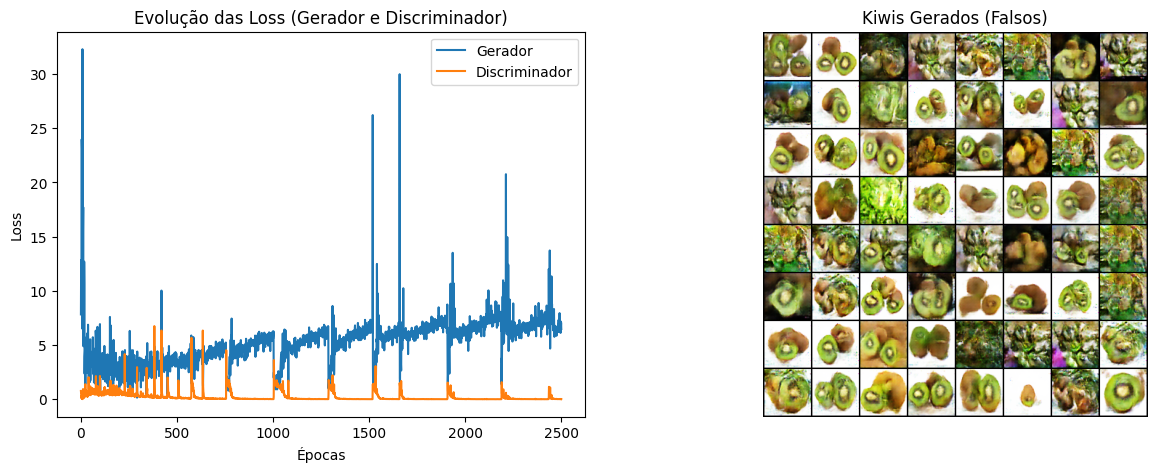

In [8]:
with torch.no_grad():
    fake_display = netG(fixed_noise).detach().cpu()

plt.figure(figsize=(15, 5))

# Plot das perdas (Loss)
plt.subplot(1, 2, 1)
plt.title("Evolução das Loss (Gerador e Discriminador)")
plt.plot(G_losses, label="Gerador")
plt.plot(D_losses, label="Discriminador")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# Plot das imagens geradas
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Kiwis Gerados (Falsos)")
plt.imshow(np.transpose(vutils.make_grid(fake_display[:64], padding=2, normalize=True).cpu(),(1,2,0)))

plt.show()

🔍 Gerando milhares de kiwis falsos e pedindo a avaliação do Discriminador...
🏆 Melhor nota alcançada: 67.32% de chance de ser real (segundo o D)
📉 Pior nota dentro do Top 64: 17.24% de chance de ser real


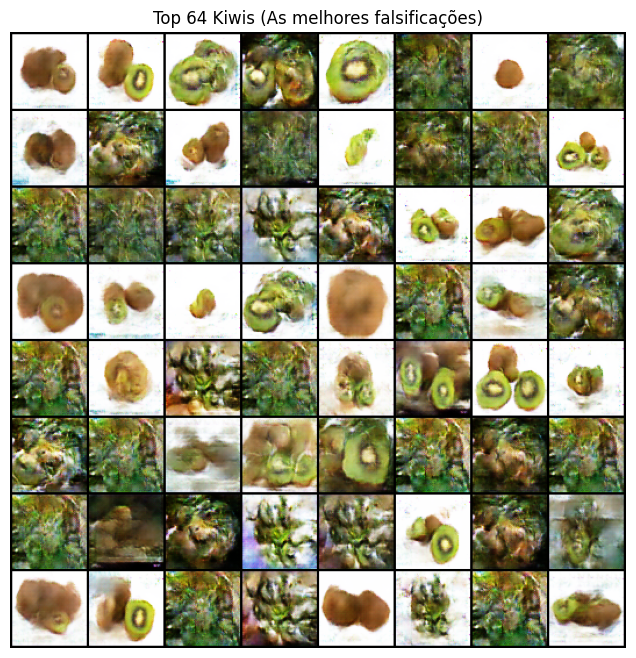

In [9]:
print("🔍 Gerando milhares de kiwis falsos e pedindo a avaliação do Discriminador...")

# Modelos em modo de avaliação (desliga o cálculo de gradientes e ajusta o BatchNorm)
netG.eval()
netD.eval()

with torch.no_grad():
    # 1. Gerar um lote gigante de imagens (ex: 1000 imagens falsas)
    qnt_teste = 1000
    ruido_teste = torch.randn(qnt_teste, latent_dim, 1, 1, device=device)
    kiwis_falsos = netG(ruido_teste)
    
    # 2. Pedir para o Discriminador dar a "nota"
    # Como a última camada do D é uma Sigmoid, a saída é entre 0 (falso) e 1 (real)
    notas = netD(kiwis_falsos)
    
    # 3. Pegar os índices das 64 maiores notas usando o topk do PyTorch
    melhores_notas, melhores_indices = torch.topk(notas, 64)
    
    # 4. Filtrar apenas as melhores imagens usando os índices
    melhores_kiwis = kiwis_falsos[melhores_indices]

# 5. Mostrar o resultado
print(f"🏆 Melhor nota alcançada: {melhores_notas[0].item() * 100:.2f}% de chance de ser real (segundo o D)")
print(f"📉 Pior nota dentro do Top 64: {melhores_notas[-1].item() * 100:.2f}% de chance de ser real")

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Top 64 Kiwis (As melhores falsificações)")
plt.imshow(np.transpose(vutils.make_grid(melhores_kiwis, padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()